In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Load & Explore Data

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
print(df.dtypes)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df.describe())
print(df.isnull().sum())

Shape: (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7032.000000
mean        0.162147    32.371149       64.761692   2283.300441
std         0.368612    24.559481       30.090047   2266.771362
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    401.450

## Data Cleaning

In [3]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
print("Duplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Shape After Removing Duplicates:", df.shape)

Duplicate Rows: 0
Shape After Removing Duplicates: (7043, 21)


## Outlier Removal

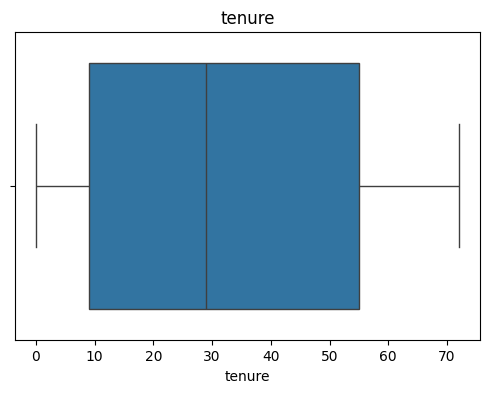

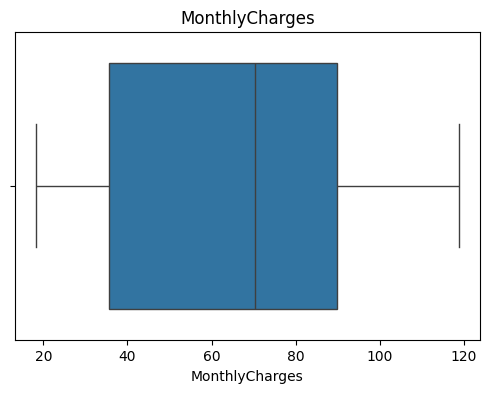

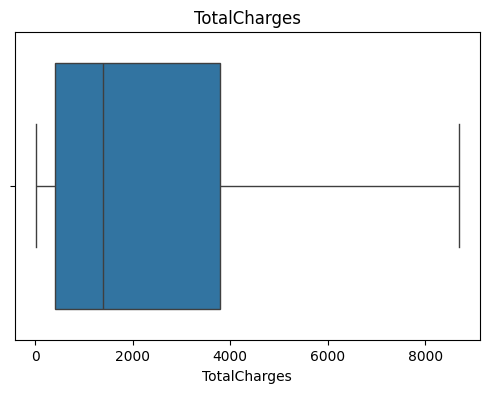

Shape After Outlier Removal: (7043, 21)


In [4]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Shape After Outlier Removal:", df.shape)

## Visualizations

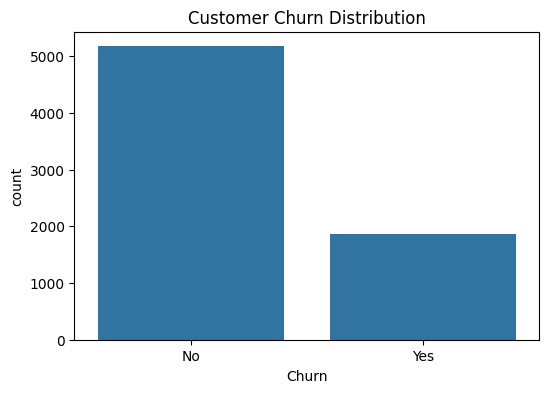

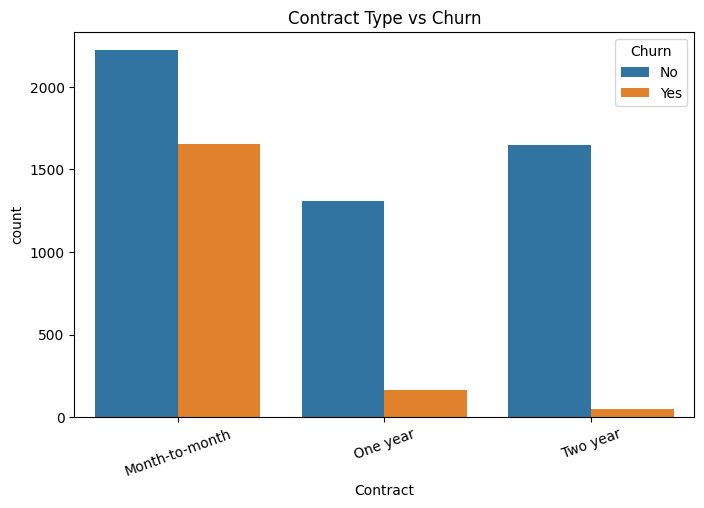

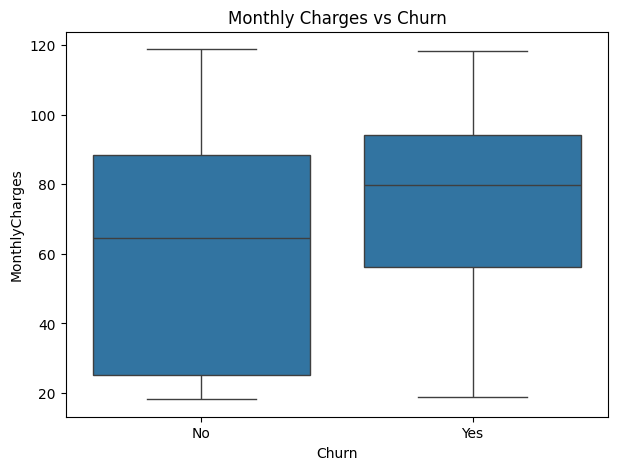

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=20)
plt.title("Contract Type vs Churn")
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

## Feature Engineering & Encoding

In [6]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
df.drop("customerID", axis=1, inplace=True)
cat_cols = df.select_dtypes(include="object").columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df.drop("Churn", axis=1)
y = df["Churn"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training & Evaluation

In [7]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Logistic Regression Accuracy:", acc_lr)
print(classification_report(y_test, y_pred_lr))
print("Decision Tree Accuracy:", acc_dt)
print(classification_report(y_test, y_pred_dt))
print("Random Forest Accuracy:", acc_rf)
print(classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.8197303051809794
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

Decision Tree Accuracy: 0.7068843151171044
              precision    recall  f1-score   support

           0       0.80      0.80      0.80      1036
           1       0.45      0.45      0.45       373

    accuracy                           0.71      1409
   macro avg       0.62      0.63      0.63      1409
weighted avg       0.71      0.71      0.71      1409

Random Forest Accuracy: 0.7913413768630234
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.65      0.46      0.54       373

    accuracy                           0.79    

## Model Comparison

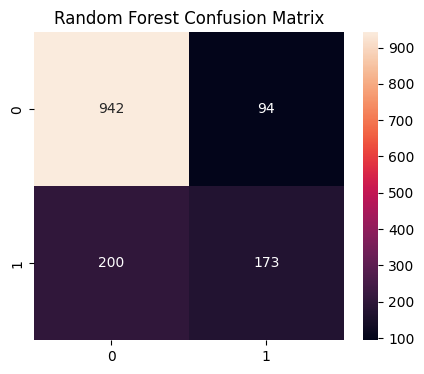

                 Model  Accuracy
0  Logistic Regression  0.819730
1        Decision Tree  0.706884
2        Random Forest  0.791341

Best Model:
Model       Logistic Regression
Accuracy                0.81973
Name: 0, dtype: object


In [8]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.show()

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [acc_lr, acc_dt, acc_rf]
})
print(comparison)
best_model = comparison.loc[comparison["Accuracy"].idxmax()]
print("\nBest Model:")
print(best_model)